In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist


In [5]:
# ======================================
# 1️⃣ Load MNIST Dataset
# ======================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


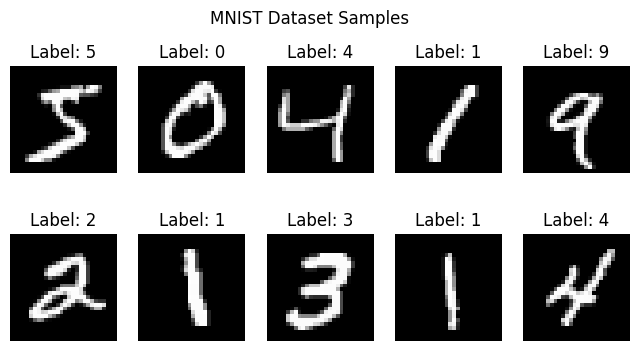

In [6]:
# ======================================
# 2️⃣ Show some dataset samples
# ======================================

plt.figure(figsize=(8,4))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.suptitle("MNIST Dataset Samples")
plt.show()

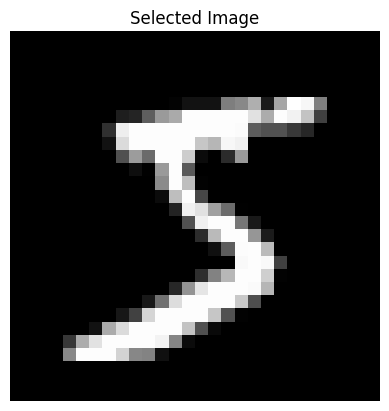

In [7]:
# ======================================
# 3️⃣ Select one image
# ======================================

img = x_train[0]

plt.imshow(img, cmap='gray')
plt.title("Selected Image")
plt.axis("off")
plt.show()

In [8]:
# ======================================
# 4️⃣ Resize manually to 64x128
# ======================================

height, width = img.shape

new_width = 64
new_height = 128

img_resized = np.zeros((new_height,new_width))

for i in range(new_height):
    for j in range(new_width):

        x = int(j * width / new_width)
        y = int(i * height / new_height)

        img_resized[i,j] = img[y,x]


In [9]:
# ======================================
# 5️⃣ Manual Sobel Convolution
# ======================================

sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

gx = np.zeros_like(img_resized)
gy = np.zeros_like(img_resized)

rows, cols = img_resized.shape

for i in range(1, rows-1):
    for j in range(1, cols-1):

        region = img_resized[i-1:i+2, j-1:j+2]

        gx[i,j] = np.sum(region * sobel_x)
        gy[i,j] = np.sum(region * sobel_y)



In [10]:
# ======================================
# 6️⃣ Magnitude & Angle
# ======================================

magnitude = np.sqrt(gx**2 + gy**2)

angle = np.rad2deg(np.arctan2(gy,gx)) % 180


In [11]:
# ======================================
# 7️⃣ HOG Histogram (Method 4)
# ======================================

cell_size = 8
bins = 9
bin_size = 180 / bins

num_cells_y = rows // cell_size
num_cells_x = cols // cell_size

hog = np.zeros((num_cells_y, num_cells_x, bins))

for i in range(num_cells_y):
    for j in range(num_cells_x):

        mag_cell = magnitude[
            i*cell_size:(i+1)*cell_size,
            j*cell_size:(j+1)*cell_size
        ]

        ang_cell = angle[
            i*cell_size:(i+1)*cell_size,
            j*cell_size:(j+1)*cell_size
        ]

        hist = np.zeros(bins)

        for y in range(cell_size):
            for x in range(cell_size):

                ang = ang_cell[y,x]
                mag = mag_cell[y,x]

                bin_index = ang/bin_size

                lower = int(np.floor(bin_index)) % bins
                upper = (lower+1)%bins

                ratio_upper = bin_index-lower
                ratio_lower = 1-ratio_upper

                hist[lower] += mag*ratio_lower
                hist[upper] += mag*ratio_upper

        hog[i,j] = hist

In [12]:
# ======================================
# 8️⃣ Block Normalization (16x16)
# ======================================

blocks = []

for i in range(num_cells_y-1):
    for j in range(num_cells_x-1):

        block = hog[i:i+2,j:j+2].ravel()

        norm = np.sqrt(np.sum(block**2)) + 0.0001

        block = block / norm

        blocks.append(block)


hog_feature_vector = np.concatenate(blocks)

print("HOG Feature Vector Length:", len(hog_feature_vector))


HOG Feature Vector Length: 3780


In [13]:
# ======================================
# 9 Concatenate histograms → feature vector
# ======================================

hog_feature_vector = np.concatenate(blocks)

print("Feature Vector Length:", len(hog_feature_vector))

np.set_printoptions(threshold=np.inf)

print("HOG Feature Vector:")
print(hog_feature_vector)

Feature Vector Length: 3780
HOG Feature Vector:
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.0000

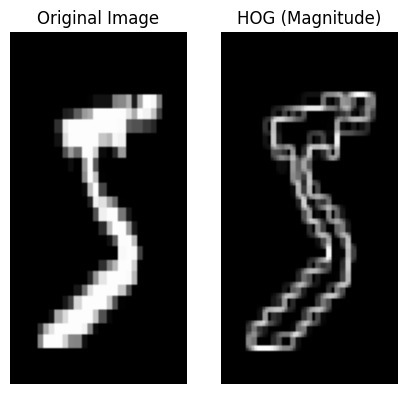

In [ ]:

plt.figure(figsize=(5,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(img_resized, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# HOG (Magnitude)
plt.subplot(1,2,2)
plt.imshow(magnitude, cmap='gray')
plt.title("HOG (Magnitude)")
plt.axis("off")

plt.show()

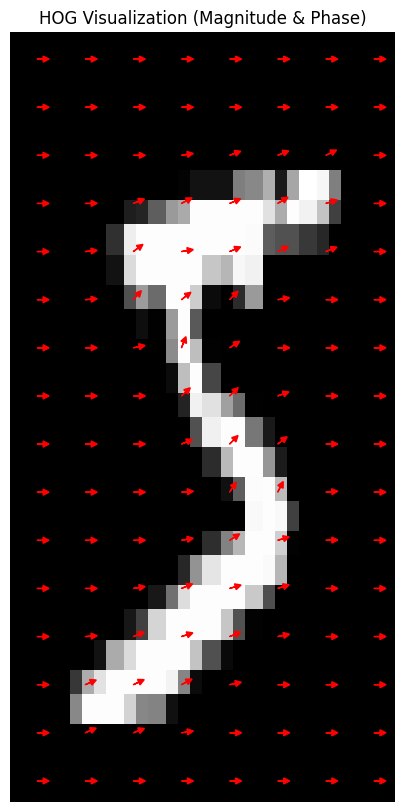

In [ ]:
# ======================================
#  Draw HOG over the image (Magnitude & Phase)
# ======================================

plt.figure(figsize=(6,10))
plt.imshow(img_resized, cmap='gray')

for i in range(0, rows, cell_size):
    for j in range(0, cols, cell_size):

        # get mag and angle for each cell
        cell_mag = magnitude[i:i+cell_size, j:j+cell_size]
        cell_ang = angle[i:i+cell_size, j:j+cell_size]

        # average magnitude and angle
        #to represent the whole cell with one magnitude and one direction.”
        m = np.mean(cell_mag)
        a = np.mean(cell_ang)

        # convert angle to radians
        rad = np.deg2rad(a)

        dx =  np.cos(rad)
        dy =  np.sin(rad)

        
        plt.arrow(
            j + cell_size/2,
            i + cell_size/2,
            dx,
            -dy,
            color='red',
            head_width=1,
            head_length=1
        )

plt.title("HOG Visualization (Magnitude & Phase)")
plt.axis("off")
plt.show()